In [12]:
import pandas as pd

data = {
    "hours_studied":  [1,   2,  3,  4,  5,  6,  7,  8,  9, 10,  2,  4],
    "attendance":     [50, 55, 60, 65, 70, 75, 80, 85, 52, 90, 40, 80],
    "passed":         [0,   0,  0,  0,  1,  1,  1,  1,  1,  1,  0,  1]
}

df = pd.DataFrame(data)
df

,hours_studied,attendance,passed
0,1,50,0
1,2,55,0
2,3,60,0
3,4,65,0
4,5,70,1
5,6,75,1
6,7,80,1
7,8,85,1
8,9,52,1
9,10,90,1


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[["hours_studied", "attendance"]]
y = df["passed"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Train model
model = DecisionTreeClassifier(random_state=42, max_depth=3)
model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



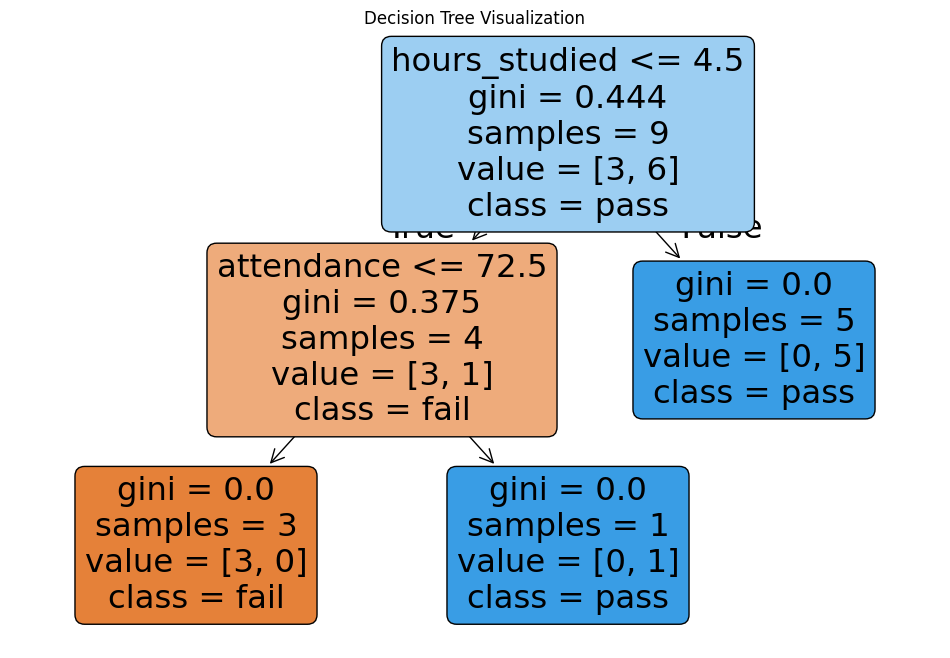

In [20]:
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt

# Visualize tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=["hours_studied", "attendance"],
    class_names=["fail", "pass"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

C:\DEV\python\python-ML-DL\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


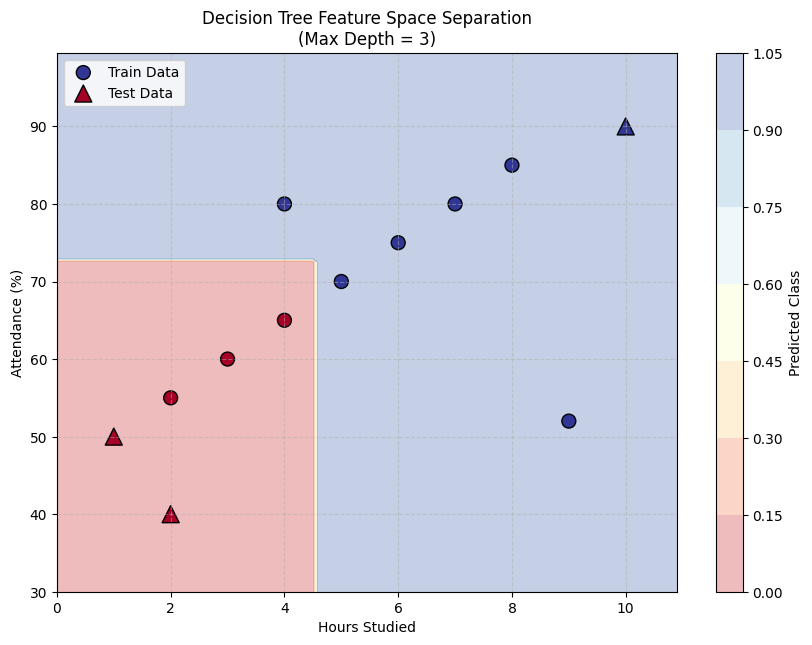

In [21]:
import numpy as np

# 3. Create Mesh Grid for Visualization
# Determine the min and max for each feature to set the plot limits
x_min, x_max = X["hours_studied"].min() - 1, X["hours_studied"].max() + 1
y_min, y_max = X["attendance"].min() - 10, X["attendance"].max() + 10

# Create a dense grid of points
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),  # Step size 0.1 for smoothness
    np.arange(y_min, y_max, 0.5)   # Step size 0.5 for smoothness
)

# Flatten the grid to predict each point
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for every point in the grid
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)  # Reshape back to grid dimensions

# 4. Plotting
plt.figure(figsize=(10, 7))

# Plot the decision boundary (colored regions)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.colorbar(label="Predicted Class")

# Plot the training points
scatter = plt.scatter(
    X_train["hours_studied"],
    X_train["attendance"],
    c=y_train,
    edgecolors='k',
    s=100,
    cmap=plt.cm.RdYlBu,
    label="Train Data"
)

# Plot the test points (with different marker style to distinguish)
plt.scatter(
    X_test["hours_studied"],
    X_test["attendance"],
    c=y_test,
    edgecolors='k',
    s=150,
    marker='^',
    cmap=plt.cm.RdYlBu,
    label="Test Data"
)

# Labels and Title
plt.xlabel("Hours Studied")
plt.ylabel("Attendance (%)")
plt.title("Decision Tree Feature Space Separation\n(Max Depth = 3)")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()